In [1]:
%load_ext autoreload
%autoreload 2

from WhiteDwarf.wd_setup import WhiteDwarf
import WhiteDwarf.source as source
import numpy as np
from tqdm import tqdm
import pandas as pd
from WhiteDwarf.constants import *
import os

def iterate(rhoc_scaled, source_function, max_iter=20, epsilon=5e-4, DEBUG=False, dr=1e-3, **kwargs):
    wd = WhiteDwarf(Ye=0.5, rhoc_scaled=rhoc_scaled, source=source_function, Z=6, dr=dr, **kwargs)
    wd.hydro_integrate(DEBUG=DEBUG)
    para0 = wd.thermo_integrate(DEBUG=DEBUG)
    #print(f"r (km) {wd.rbar2r(para0[0]):.3e}, rho (g/cc): {wd.rhobar2rho(para0[1]):.3e}, M (Msolar): {wd.mbar2m(para0[2]):.3e}, T (K): {(para0[3] * wd.rho0 * c ** 2/ a) ** 0.25:.3e}, Luminosity: {source_function.luminosity(r=wd.R_profile[0] * wd.R0, m=wd.M_profile[-1] * wd.M0):.3e}")

    print("Finished initial setup.\n")
    for n in range(max_iter):
        print(f"Round {n}: hydro")
        wd.hydro_integrate(DEBUG=DEBUG)
        print(f"Round {n}: thermal")
        para = wd.thermo_integrate(DEBUG=DEBUG)
        #print(f"r (km) {wd.rbar2r(para[0]):.3e}, rho (g/cc): {wd.rhobar2rho(para[1]):.3e}, M (Msolar): {wd.mbar2m(para[2]):.3e}, T (K): {(para[3] * wd.rho0/ a) ** 0.25:.3e}, Luminosity: {source_function.luminosity(r=wd.R_profile[0] * wd.R0, m=wd.M_profile[-1] * wd.M0):.3e}")
        

        eps = np.nanmax(np.abs(para-para0)/para0)
        if (eps <= epsilon).all():
            print(f"Epsilon: {np.mean(eps):.3e}, Converges, BREAK")
            return wd
            
        else:
            print(f"Finished iter: {n}, epsilon: {np.mean(eps):.3e} CONTINUE")
            para0 = para

    print("===== DOESN'T CONVERGE =====")

In [22]:
PBH = source.singlePBH(1e14, N=1e15, R=1000*km2cm)
wd = iterate(1e2, PBH, DEBUG=False, dr=1e-3, epsilon=1e-4, max_iter=20)

Hawking temperature of the PBH is 1.227e+12
Using source: SinglePBH
Finish setting up white dwarf parameters 

Backward Integration: Surface T: 1.017e+05 K
Finished initial setup.

Round 0: hydro
Round 0: thermal
Backward Integration: Surface T: 1.025e+05 K
Finished iter: 0, epsilon: 2.616e-02 CONTINUE
Round 1: hydro
Round 1: thermal
Backward Integration: Surface T: 1.025e+05 K
Finished iter: 1, epsilon: 1.433e-03 CONTINUE
Round 2: hydro
Round 2: thermal
Backward Integration: Surface T: 1.025e+05 K
Epsilon: 7.493e-05, Converges, BREAK


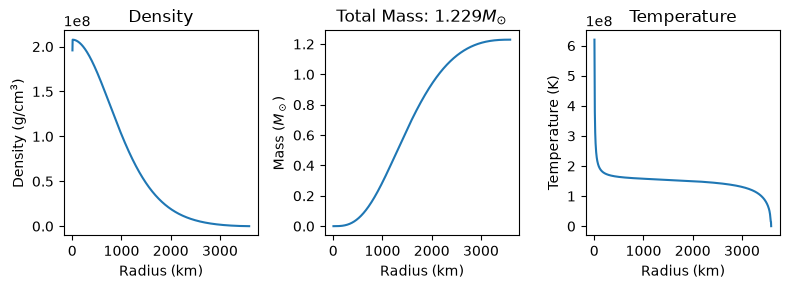

In [23]:
wd.plot(figsize=(8,3))

In [26]:
print(wd)

Mass: 0.880 Msolar, Radius: 3593.660 kmSurface Temperature: 1.025e+05, Core Temperature: 6.199e+08


In [ ]:
PBH = source.singlePBH(1e14, N=1e15, R=1000*km2cm)
wd = iterate(1e2, source.No_source(), DEBUG=False, dr=1e-3, epsilon=1e-4, max_iter=20)

In [ ]:
wd = WhiteDwarf(Ye=0.5, rhoc_scaled=1e2, source=source.No_source, Z=6, dr=dr, **kwargs)
wd.hydro_integrate()
    

Mass: 0.000 Msolar, Radius: 3.860 kmSurface Temperature: 0.000e+00, Core Temperature: 0.000e+00
